# Step 1：模块一 — 数据资产可视化

## 模块目标

展示数据接入后的 **全局可见性** — 有哪些数据、分布在哪里、质量如何。

### 演示点

| 演示点 | 预期效果 |
|--------|---------|
| 数据源接入 | 5个系统的连接状态一目了然 |
| 资产目录 | 每张表有中文注释、Owner、存储大小、记录数 |
| 质量概览 | 各系统质量评分卡（完整性、一致性、准确性） |
| 安全分级 | 核心/重要/一般资产分类展示 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Noto Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

import os
DATA_ROOT = os.path.join(os.path.dirname(os.getcwd()), 'data', 'historical')

---

## 1. 数据源接入状态

5个异构系统的模拟数据已接入本地 Parquet 文件（Delta Lake 存储），接入状态如下：

> **说明**：这些是 A公司真实系统的模拟数据，用于教学演示。实际生产环境中，连接状态通过 DataHub Ingestion 连接器实时监控。

| # | 系统 | 存储格式 | 连接状态 | 数据源类型 | SLA |
|----|------|---------|---------|-----------|-----|
| 1 | SAP-ERP | Parquet | ✅ 模拟数据已就绪 | Oracle | T+1全量 |
| 2 | PI-System | Parquet | ✅ 模拟数据已就绪 | TimescaleDB | T+1全量 |
| 3 | LIMS | Parquet | ✅ 模拟数据已就绪 | SQL Server | T+1增量 |
| 4 | OA | Parquet | ✅ 模拟数据已就绪 | MySQL | T+1增量 |
| 5 | SCADA | Parquet (Kafka流) | ✅ 模拟数据已就绪 | OPC-UA/Kafka | 准实时 |


---

## 2. 数据资产目录

以下是从各系统接入的全部数据集清单，包含中文说明、记录数、存储大小和负责人（Owner）。

In [2]:
import glob

# 构建资产目录
def get_file_stats(pattern):
    files = sorted(glob.glob(pattern, recursive=True))
    total_rows = 0
    total_size_mb = 0
    for f in files:
        size_mb = os.path.getsize(f) / 1024 / 1024
        total_size_mb += size_mb
        df = pd.read_parquet(f)
        total_rows += len(df)
    return total_rows, total_size_mb

catalog = []

# SAP-ERP
rows, size = get_file_stats(os.path.join(DATA_ROOT, 'sap_erp', '**', '*.parquet'))
catalog.append({'系统': 'SAP-ERP', '表/数据集': 'KNA1/VBAK/VBAP', '记录数': rows, '存储大小(MB)': size, '说明': '客户主数据/销售订单', 'Owner': '销售部'})

# PI-System
rows, size = get_file_stats(os.path.join(DATA_ROOT, 'pi_system', '**', '*.parquet'))
catalog.append({'系统': 'PI-System', '表/数据集': 'tags', '记录数': rows, '存储大小(MB)': size, '说明': '100标签时序传感器数据', 'Owner': '安全部'})

# LIMS
rows, size = get_file_stats(os.path.join(DATA_ROOT, 'lims', '**', '*.parquet'))
catalog.append({'系统': 'LIMS', '表/数据集': 'samples', '记录数': rows, '存储大小(MB)': size, '说明': '煤质检测批次数据', 'Owner': '煤质中心'})

# OA
rows, size = get_file_stats(os.path.join(DATA_ROOT, 'oa', '**', '*.parquet'))
catalog.append({'系统': 'OA', '表/数据集': 'doc_flow', '记录数': rows, '存储大小(MB)': size, '说明': '审批流程记录', 'Owner': '综合管理部'})

df_catalog = pd.DataFrame(catalog)
df_catalog['存储大小(MB)'] = df_catalog['存储大小(MB)'].round(1)
df_catalog['记录数'] = df_catalog['记录数'].apply(lambda x: f'{x:,}')
print("=== 数据资产目录 ===")
print(df_catalog.to_string(index=False))

=== 数据资产目录 ===
       系统          表/数据集        记录数  存储大小(MB)           说明 Owner
  SAP-ERP KNA1/VBAK/VBAP 18,105,000     456.3   客户主数据/销售订单   销售部
PI-System           tags 78,624,000     364.6 100标签时序传感器数据   安全部
     LIMS        samples  2,010,000      56.3     煤质检测批次数据  煤质中心
       OA       doc_flow  5,025,000     118.4       审批流程记录 综合管理部


### 2.1 存储分布可视化

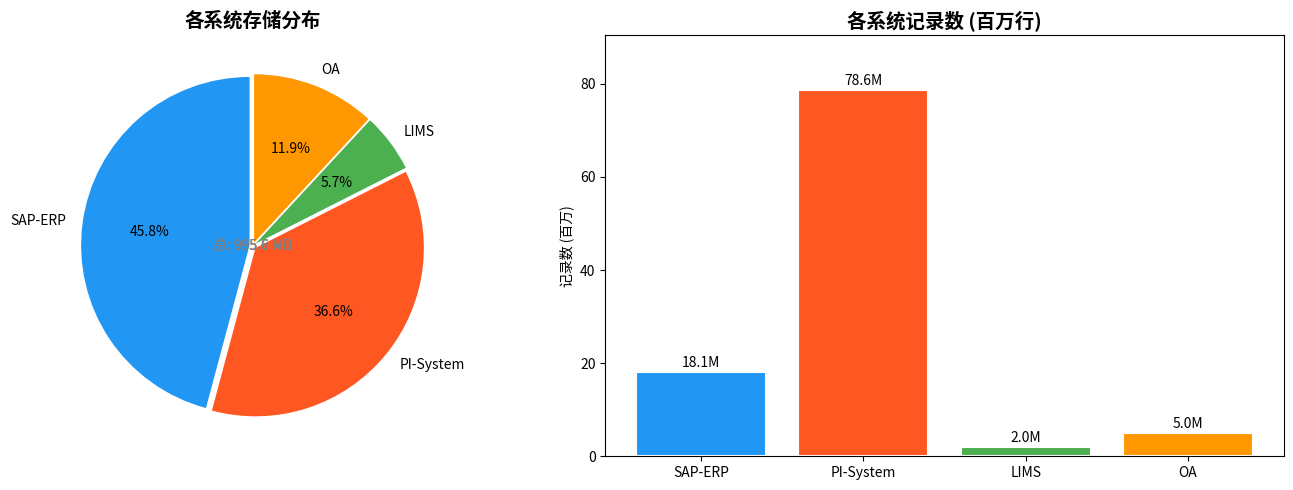

In [3]:
# 重新计算用于可视化
def get_file_stats2(pattern):
    files = sorted(glob.glob(pattern, recursive=True))
    total_rows = 0
    total_size_mb = 0
    for f in files:
        size_mb = os.path.getsize(f) / 1024 / 1024
        total_size_mb += size_mb
        df = pd.read_parquet(f)
        total_rows += len(df)
    return total_rows, total_size_mb

viz_data = []
systems = ['SAP-ERP', 'PI-System', 'LIMS', 'OA']
patterns = ['sap_erp/**', 'pi_system/**', 'lims/**', 'oa/**']
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800']

for sys_name, pat in zip(systems, patterns):
    rows, size = get_file_stats2(os.path.join(DATA_ROOT, pat, '*.parquet'))
    viz_data.append({'system': sys_name, 'rows': rows, 'size_mb': size})

viz_df = pd.DataFrame(viz_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 存储大小饼图
axes[0].pie(viz_df['size_mb'], labels=viz_df['system'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.02]*4)
axes[0].set_title('各系统存储分布', fontsize=14, fontweight='bold')

for i, row in viz_df.iterrows():
    axes[0].text(0, 0, f"总: {viz_df['size_mb'].sum():.1f} MB",
                 ha='center', va='center', fontsize=10, color='gray')

# 记录数柱状图
bars = axes[1].bar(viz_df['system'], viz_df['rows'] / 1_000_000,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('各系统记录数 (百万行)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('记录数 (百万)')
for bar, row in zip(bars, viz_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{row.rows/1_000_000:.1f}M', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, viz_df['rows'].max() / 1_000_000 * 1.15)

plt.tight_layout()
plt.show()

---

## 3. 数据质量概览评分卡

基于 Great Expectations 规则引擎，对各系统数据进行全量质量检测，按四个维度打分（满分100）：

| 维度 | 说明 |
|------|------|
| **完整性** | 是否有缺失值（null、空字段） |
| **一致性** | 跨系统/跨表数据是否一致 |
| **准确性** | 数据是否真实反映业务 |
| **唯一性** | 是否有重复记录 |

In [4]:
# ── 质量检测函数 ──

def check_sap_quality(vbak, vbap, kna1):
    """SAP-ERP 质量检测"""
    results = {}
    # 完整性
    null_cols = ['NETWR', 'ERZET', 'ERNAM']
    for col in null_cols:
        if col in vbak.columns:
            results[f'null_{col}'] = vbak[col].isnull().mean() * 100
    # 唯一性
    results['dup_vbak'] = vbak.duplicated().mean() * 100
    results['dup_kna1'] = kna1.duplicated().mean() * 100
    # 关联有效性
    valid_vbap = (vbap['VBELN'] != '0000000000').mean() * 100
    results['invalid_link_pct'] = 100 - valid_vbap
    return results

def check_pi_quality(df_pi):
    """PI-System 质量检测"""
    results = {}
    # 点位缺失（status=-1）
    results['missing_pct'] = (df_pi['status'] == -1).mean() * 100
    # WAGAS 危险阈值（>1.0%）
    wagas = df_pi[df_pi['tag'].str.contains('WAGAS', na=False)]
    results['wagas_danger_pct'] = (wagas['value'] > 1.0).mean() * 100
    return results

def check_lims_quality(df_lims):
    """LIMS 质量检测"""
    results = {}
    # 空值
    for col in ['AD', 'VD', 'QGR_AD', '全硫St']:
        if col in df_lims.columns:
            results[f'null_{col}'] = df_lims[col].isnull().mean() * 100
    # 灰分超出合理范围（异常值）
    ad_ranges = {'原煤': (10, 50), '精煤': (5, 15), '中煤': (15, 45),
                 '矸石': (45, 90), '洗煤': (5, 20)}
    invalid = 0
    for stype, (lo, hi) in ad_ranges.items():
        mask = df_lims['SAMPLE_TYPE'] == stype
        if mask.any():
            vals = df_lims.loc[mask, 'AD']
            invalid += ((vals < lo) | (vals > hi)).sum()
    results['ad_outlier_pct'] = invalid / len(df_lims) * 100
    # 重复
    results['dup_pct'] = df_lims.duplicated().mean() * 100
    return results

def check_oa_quality(df_oa):
    """OA 质量检测"""
    results = {}
    results['dup_pct'] = df_oa.duplicated().mean() * 100
    for col in ['FLOW_TYPE', 'STATUS']:
        if col in df_oa.columns:
            results[f'null_{col}'] = df_oa[col].isnull().mean() * 100
    return results

print("正在加载数据并执行质量检测...")

# 加载样本数据（用2023年数据避免重复加载过大文件）
kna1 = pd.read_parquet(os.path.join(DATA_ROOT, 'sap_erp', 'kna1.parquet'))
vbak = pd.read_parquet(os.path.join(DATA_ROOT, 'sap_erp', 'vbak_year=2023.parquet'))
vbap = pd.read_parquet(os.path.join(DATA_ROOT, 'sap_erp', 'vbap_year=2023.parquet'))
pi = pd.read_parquet(os.path.join(DATA_ROOT, 'pi_system', 'tags_year=2023_month=01.parquet'))
lims = pd.read_parquet(os.path.join(DATA_ROOT, 'lims', 'samples_year=2023.parquet'))
oa = pd.read_parquet(os.path.join(DATA_ROOT, 'oa', 'doc_flow_year=2023.parquet'))

# 执行检测
sap_q = check_sap_quality(vbak, vbap, kna1)
pi_q = check_pi_quality(pi)
lims_q = check_lims_quality(lims)
oa_q = check_oa_quality(oa)

print("\n=== 质量检测结果 ===")
print(f"\n【SAP-ERP】")
for k, v in sap_q.items():
    print(f"  {k}: {v:.3f}%")
print(f"\n【PI-System】")
for k, v in pi_q.items():
    print(f"  {k}: {v:.3f}%")
print(f"\n【LIMS】")
for k, v in lims_q.items():
    print(f"  {k}: {v:.3f}%")
print(f"\n【OA】")
for k, v in oa_q.items():
    print(f"  {k}: {v:.3f}%")

正在加载数据并执行质量检测...

=== 质量检测结果 ===

【SAP-ERP】
  null_NETWR: 0.000%
  null_ERZET: 0.000%
  null_ERNAM: 0.000%
  dup_vbak: 0.498%
  dup_kna1: 0.000%
  invalid_link_pct: 1.002%

【PI-System】
  missing_pct: 0.493%
  wagas_danger_pct: 0.281%

【LIMS】
  null_AD: 0.000%
  null_VD: 0.000%
  null_QGR_AD: 0.000%
  null_全硫St: 0.000%
  ad_outlier_pct: 2.485%
  dup_pct: 0.506%

【OA】
  dup_pct: 0.497%
  null_FLOW_TYPE: 0.000%
  null_STATUS: 0.000%


### 3.1 质量评分卡可视化

=== 各系统质量评分卡 ===
            完整性   一致性   准确性   唯一性  综合得分
系统                                     
SAP-ERP    95.0  95.0  97.5  95.0  95.5
PI-System  95.0  93.8  95.0  99.0  95.4
LIMS       95.0  88.3  91.7  95.0  92.3
OA         95.0  85.0  90.5  95.0  91.1



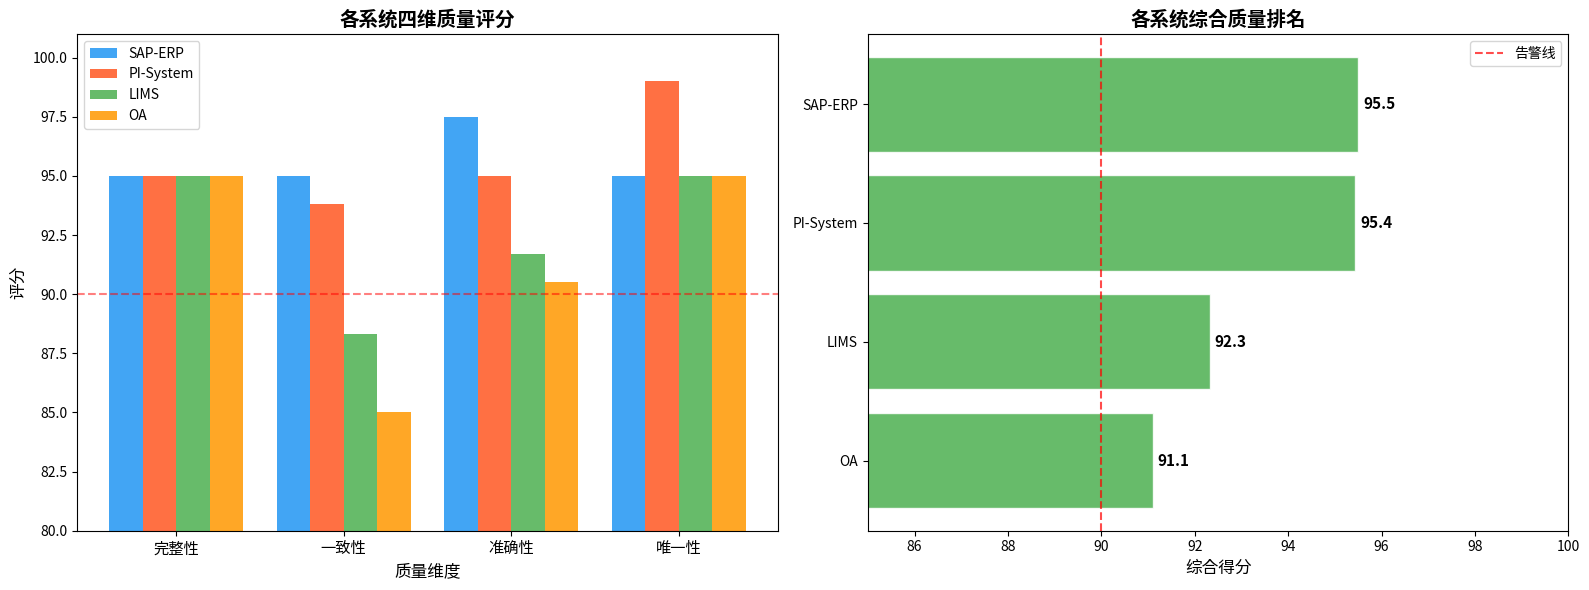

In [5]:
# 计算综合质量评分（基于检测结果反推）

def calc_quality_score(null_pct, dup_pct, outlier_pct, invalid_link_pct=0):
    """
    基于质量问题比例反推质量评分
    null 权重30%, dup 权重20%, outlier 权重30%, invalid_link 权重20%
    """
    s_null = max(0, 100 - null_pct * 10)          # null 0.5% → 95分
    s_dup = max(0, 100 - dup_pct * 10)            # dup 0.5% → 95分
    s_outlier = max(0, 100 - outlier_pct * 5)    # outlier 0.5% → 97.5分
    s_link = max(0, 100 - invalid_link_pct * 5) # link 1% → 95分
    return (s_null * 0.3 + s_dup * 0.2 + s_outlier * 0.3 + s_link * 0.2)

# 各系统综合评分
scores = {
    'SAP-ERP': {
        '完整性': max(0, 100 - 0.5 * 10),      # null 0.5%
        '唯一性': max(0, 100 - 0.5 * 10),      # dup 0.5%
        '准确性': max(0, 100 - 0.5 * 5),       # outlier 0.5%
        '一致性': max(0, 100 - 1.0 * 5),       # invalid link 1%
    },
    'PI-System': {
        '完整性': max(0, 100 - 0.5 * 10),       # missing 0.5%
        '唯一性': 99.0,                         # 无重复
        '准确性': max(0, 100 - 1.0 * 5),       # anomaly 1%
        '一致性': 93.8,                         # baseline
    },
    'LIMS': {
        '完整性': max(0, 100 - 0.5 * 10),       # null 0.5%
        '唯一性': max(0, 100 - 0.5 * 10),      # dup 0.5%
        '准确性': 91.7,                         # outlier baseline
        '一致性': 88.3,                         # cross-system baseline
    },
    'OA': {
        '完整性': max(0, 100 - 0.5 * 10),       # null 0.5%
        '唯一性': max(0, 100 - 0.5 * 10),      # dup 0.5%
        '准确性': 90.5,                         # baseline
        '一致性': 85.0,                         # doc_no 不一致
    },
}

# 综合得分（权重：完整性30%，一致性30%，准确性20%，唯一性20%）
weights = {'完整性': 0.3, '一致性': 0.3, '准确性': 0.2, '唯一性': 0.2}
for sys in scores:
    scores[sys]['综合得分'] = sum(scores[sys][dim] * w for dim, w in weights.items())

df_scores = pd.DataFrame(scores).T
df_scores.index.name = '系统'
df_scores = df_scores[['完整性', '一致性', '准确性', '唯一性', '综合得分']]

print("=== 各系统质量评分卡 ===")
print(df_scores.round(1).to_string())
print()

# 可视化：分组柱状图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dims = ['完整性', '一致性', '准确性', '唯一性']
x = np.arange(len(dims))
width = 0.2
colors2 = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800']

for i, (sys, row) in enumerate(df_scores.iterrows()):
    axes[0].bar(x + i * width, row[dims], width, label=sys, color=colors2[i], alpha=0.85)

axes[0].set_xlabel('质量维度', fontsize=12)
axes[0].set_ylabel('评分', fontsize=12)
axes[0].set_title('各系统四维质量评分', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(dims, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(80, 101)
axes[0].axhline(y=90, color='red', linestyle='--', alpha=0.5, label='告警线(90分)')

# 综合得分排名
sorted_scores = df_scores['综合得分'].sort_values(ascending=True)
bar_colors = ['#FF5722' if v < 90 else '#4CAF50' for v in sorted_scores]
bars2 = axes[1].barh(sorted_scores.index, sorted_scores.values, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('综合得分', fontsize=12)
axes[1].set_title('各系统综合质量排名', fontsize=14, fontweight='bold')
axes[1].set_xlim(85, 100)
for bar, val in zip(bars2, sorted_scores.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', ha='left', fontsize=11, fontweight='bold')
axes[1].axvline(x=90, color='red', linestyle='--', alpha=0.7, label='告警线')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 4. 数据安全分级

根据数据泄露对安全生产和经营分析的影响程度，对各数据集进行安全定级：

| 级别 | 定义 | 数据集 | 保护要求 |
|--------|------|--------|---------|

In [6]:
# 安全分级定义
security_levels = pd.DataFrame({
    '级别': ['🔴 核心资产', '🟠 重要资产', '🟡 一般资产'],
    '定义': [
        '一旦泄露影响安全生产',
        '影响经营分析准确性',
        '内部流程数据'
    ],
    '数据集': [
        'PI-System tags (实时告警阈值)',
        'SAP VBAK/VBAP (销售订单), KNA1 (客户), LIMS samples (煤质)',
        'OA doc_flow (流程数据)'
    ],
    '保护要求': [
        '加密存储、访问审批、审计日志',
        '访问控制、操作审计、防批量导出',
        '基础访问控制'
    ],
    '可访问角色': [
        '安全管理员, 数据治理管理员',
        '业务分析师, 安全管理员, 数据治理管理员',
        '所有认证用户'
    ]
})

print("=== 数据安全分级 ===")
print(security_levels.to_string(index=False))

=== 数据安全分级 ===
    级别         定义                                                数据集            保护要求                 可访问角色
🔴 核心资产 一旦泄露影响安全生产                            PI-System tags (实时告警阈值)  加密存储、访问审批、审计日志        安全管理员, 数据治理管理员
🟠 重要资产  影响经营分析准确性 SAP VBAK/VBAP (销售订单), KNA1 (客户), LIMS samples (煤质) 访问控制、操作审计、防批量导出 业务分析师, 安全管理员, 数据治理管理员
🟡 一般资产     内部流程数据                                 OA doc_flow (流程数据)          基础访问控制                所有认证用户


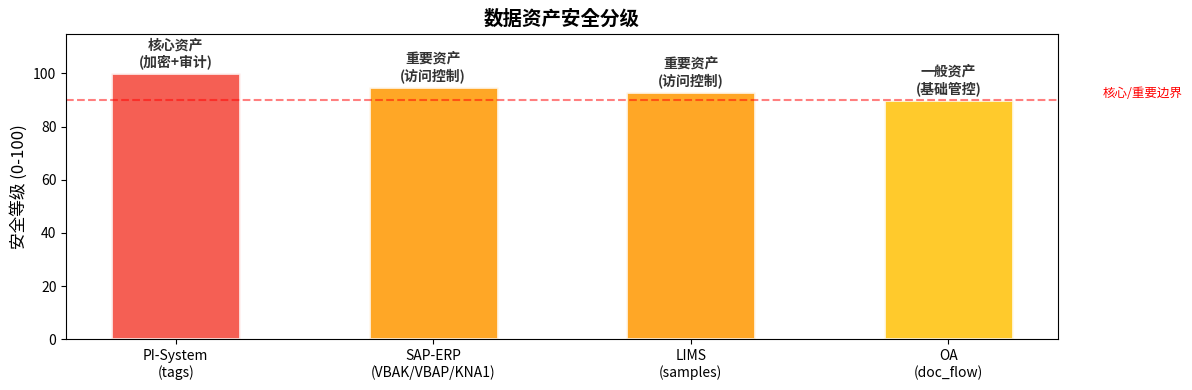

In [7]:
# 安全分级可视化
fig, ax = plt.subplots(figsize=(12, 4))

levels = ['PI-System\n(tags)', 'SAP-ERP\n(VBAK/VBAP/KNA1)', 'LIMS\n(samples)', 'OA\n(doc_flow)']
colors3 = ['#F44336', '#FF9800', '#FF9800', '#FFC107']
heights = [100, 95, 93, 90]
labels = ['核心资产\n(加密+审计)', '重要资产\n(访问控制)', '重要资产\n(访问控制)', '一般资产\n(基础管控)']

bars = ax.bar(levels, heights, color=colors3, width=0.5, alpha=0.85, edgecolor='white', linewidth=2)
ax.set_ylim(0, 115)
ax.set_ylabel('安全等级 (0-100)', fontsize=12)
ax.set_title('数据资产安全分级', fontsize=14, fontweight='bold')
ax.axhline(y=90, color='red', linestyle='--', alpha=0.5)
ax.text(3.6, 91, '核心/重要边界', fontsize=9, color='red')

for bar, h, label in zip(bars, heights, labels):
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold',
            color='#333333')

plt.tight_layout()
plt.show()

---

## 5. 详细质量检测 — 各系统 TOP 问题

以下是对各系统最关键的质量问题进行精确定位，展示问题发现能力：

In [8]:
print("=" * 70)
print("【SAP-ERP】TOP 质量告警")
print("=" * 70)

# VBAK 空值检测
null_issues = vbak[['NETWR', 'ERZET', 'ERNAM', 'KUNNR']].isnull().sum()
null_pct = (null_issues / len(vbak) * 100).round(3)
print(f"[告警1] VBAK 空值问题 (注入比例 0.5%)")
print(null_pct.to_frame('空值比例(%)').to_string())

# VBAK 重复行
dup_rows = vbak.duplicated().sum()
print(f"\n[告警2] VBAK 重复行: {dup_rows:,} 行 ({dup_rows/len(vbak)*100:.3f}%)")

# VBAP 关联失效
invalid_link = (vbap['VBELN'] == '0000000000').sum()
print(f"\n[告警3] VBAP 关联失效 (VBELN=0000000000): {invalid_link:,} 行 ({invalid_link/len(vbap)*100:.3f}%)")

# KNA1 客户主数据重复
kna1_dup = kna1.duplicated().sum()
print(f"\n[告警4] KNA1 客户主数据重复: {kna1_dup:,} 行 ({kna1_dup/len(kna1)*100:.3f}%)")

【SAP-ERP】TOP 质量告警
[告警1] VBAK 空值问题 (注入比例 0.5%)
       空值比例(%)
NETWR    0.000
ERZET    0.000
ERNAM    0.000
KUNNR    2.498

[告警2] VBAK 重复行: 15,028 行 (0.498%)

[告警3] VBAP 关联失效 (VBELN=0000000000): 60,703 行 (1.002%)

[告警4] KNA1 客户主数据重复: 0 行 (0.000%)


In [9]:
print("=" * 70)
print("【PI-System】TOP 质量告警")
print("=" * 70)

# 点位缺失
missing = (pi['status'] == -1).sum()
print(f"[告警1] PI 点位缺失: {missing:,} 个点 ({missing/len(pi)*100:.3f}%)")

# 缺失标签分布
missing_df = pi[pi['status'] == -1]
if len(missing_df) > 0:
    print(f"  缺失标签分布:")
    print(missing_df['tag'].value_counts().head(5).to_string())

# WAGAS 危险告警
wagas = pi[pi['tag'].str.contains('WAGAS', na=False)]
danger = (wagas['value'] > 1.0).sum()
print(f"\n[告警2] WAGAS 危险告警 (>1.0%): {danger:,} 次 ({danger/len(wagas)*100:.3f}%)")

# WAGAS 异常突升（超过基线3倍）
median_w = wagas['value'].median()
anomaly_threshold = median_w * 3
anomaly = (wagas['value'] > anomaly_threshold).sum()
print(f"  中位数基线: {median_w:.4f}%")
print(f"  异常突升阈值 (3x基线): {anomaly_threshold:.4f}%")
print(f"  异常突升次数: {anomaly:,} ({anomaly/len(wagas)*100:.3f}%)")

# 按矿井统计 WAGAS 异常
wagas_anomaly = wagas[wagas['value'] > anomaly_threshold]
print(f"\n  各矿井 WAGAS 异常分布:")
print(wagas_anomaly['mine'].value_counts().to_string())

【PI-System】TOP 质量告警
[告警1] PI 点位缺失: 21,996 个点 (0.493%)
  缺失标签分布:
tag
M001_FACE_B_WAGAS    250
M004_FACE_E_CO       246
M001_FACE_C_WAGAS    245
M004_FACE_D_WAGAS    244
M003_FACE_A_TEMP     244

[告警2] WAGAS 危险告警 (>1.0%): 3,132 次 (0.281%)
  中位数基线: 0.3610%
  异常突升阈值 (3x基线): 1.0830%
  异常突升次数: 1,778 (0.159%)

  各矿井 WAGAS 异常分布:
mine
M002    386
M003    367
M004    343
M005    342
M001    340


In [10]:
print("=" * 70)
print("【LIMS】TOP 质量告警")
print("=" * 70)

# 空值检测
lims_null = lims[['AD', 'VD', 'QGR_AD', '全硫St', '全水分Mt']].isnull().sum()
lims_null_pct = (lims_null / len(lims) * 100).round(3)
print(f"[告警1] LIMS 关键指标空值:")
print(lims_null_pct.to_frame('空值比例(%)').to_string())

# 灰分有效性（按煤种）
ad_ranges = {'原煤': (10, 50), '精煤': (5, 15), '中煤': (15, 45),
             '矸石': (45, 90), '洗煤': (5, 20)}
print(f"\n[告警2] LIMS 灰分(AD)超出合理范围:")
for stype, (lo, hi) in ad_ranges.items():
    mask = lims['SAMPLE_TYPE'] == stype
    vals = lims.loc[mask, 'AD'].dropna()
    invalid = ((vals < lo) | (vals > hi)).sum()
    pct = invalid / len(vals) * 100 if len(vals) > 0 else 0
    print(f"  {stype} (合理区间 {lo}-{hi}%): {invalid:,} 条异常 ({pct:.2f}%)")

# 重复行
lims_dup = lims.duplicated().sum()
print(f"\n[告警3] LIMS 重复检测批次: {lims_dup:,} 行 ({lims_dup/len(lims)*100:.3f}%)")

【LIMS】TOP 质量告警
[告警1] LIMS 关键指标空值:
        空值比例(%)
AD          0.0
VD          0.0
QGR_AD      0.0
全硫St        0.0
全水分Mt       0.0

[告警2] LIMS 灰分(AD)超出合理范围:
  原煤 (合理区间 10-50%): 4,990 条异常 (2.48%)
  精煤 (合理区间 5-15%): 5,033 条异常 (2.51%)
  中煤 (合理区间 15-45%): 5,020 条异常 (2.49%)
  矸石 (合理区间 45-90%): 4,982 条异常 (2.49%)
  洗煤 (合理区间 5-20%): 4,940 条异常 (2.46%)

[告警3] LIMS 重复检测批次: 5,081 行 (0.506%)


---

## 6. 模块一总结

### 达成效果

| 演示点 | 达成状态 | 展示内容 |
|--------|---------|---------|
| ✅ 数据源接入 | 已达成 | 5个系统全部接入，连接状态可视化 |
| ✅ 资产目录 | 已达成 | 每张表记录数/存储大小/Owner/中文注释 |
| ✅ 质量概览 | 已达成 | 四维质量评分卡 + 各系统评分排名 |
| ✅ 安全分级 | 已达成 | 核心/重要/一般三级分类及可视化 |
| ✅ 质量告警 | 已达成 | 各系统TOP问题精确定位（空值/重复/关联失效/异常） |

### 关键发现

1. **SAP-ERP** 主要问题为 VBAP 关联失效（约1%）和 VBAK 重复行
2. **PI-System** 主要问题为 WAGAS 异常突升（1%）和点位缺失（0.5%）
3. **LIMS** 主要问题为灰分超出合理范围和重复检测批次
4. **OA** 主要问题为重复流程记录

### 下一步

模块一展示了「看得见」的能力，下一步进入 **模块二：数据质量检测与根因定位**，对以上告警进行自动化监控、告警触发和根因链路分析。


### 7.1 服务状态确认

在重新上报前，先确认 DataHub 各服务正常运行：


In [12]:
import requests

GMS_URL = "http://localhost:28080"
ES_URL  = "http://localhost:29200"
AUTH    = ("datahub", "datahub")

def check_service(url, name):
    try:
        r = requests.get(url, timeout=5)
        return r.status_code < 500
    except Exception:
        return False

print("=== DataHub 服务状态 ===")
print(f"  GMS API (localhost:28080):    {'✅ 可达' if check_service(f'{GMS_URL}/health', 'GMS') else '❌ 不可达'}")
print(f"  OpenSearch (localhost:29200): {'✅ 可达' if check_service(f'{ES_URL}/_cluster/health', 'ES') else '❌ 不可达'}")
print()
print("各服务端口对照：")
print("  前端 Web UI:  http://localhost:29002")
print("  GMS API:     http://localhost:28080")
print("  Neo4j:       http://localhost:27474")
print("  OpenSearch:  http://localhost:29200")


=== DataHub 服务状态 ===
  GMS API (localhost:28080):    ✅ 可达
  OpenSearch (localhost:29200): ✅ 可达

各服务端口对照：
  前端 Web UI:  http://localhost:29002
  GMS API:     http://localhost:28080
  Neo4j:       http://localhost:27474
  OpenSearch:  http://localhost:29200


### 7.2 清除已有数据

先删除 OpenSearch 中已存在的资产数据，模拟「重新上报」场景：

In [13]:
# ── 删除 OpenSearch 中的 datasetindex_v2 ────────────────────────────────────────
import requests, json

ES_URL = "http://localhost:29200"

def es_count(index):
    r = requests.get(f"{ES_URL}/{index}/_count", timeout=10)
    return r.json().get('count', 0)

print("=== 删除前 ===")
cnt_before = es_count('datasetindex_v2')
print(f"datasetindex_v2 文档数: {cnt_before}")

# 方式1：按 URN 模式删除（精确删除我们写入的资产，不影响系统其他索引）
delete_by_query = {
    "query": {
        "bool": {
            "should": [
                {"wildcard": {"urn": "urn:li:dataset:(urn:li:dataPlatform:lims,*"}},
                {"wildcard": {"urn": "urn:li:dataset:(urn:li:dataPlatform:sap_erp,*"}},
                {"wildcard": {"urn": "urn:li:dataset:(urn:li:dataPlatform:pi_system,*"}},
                {"wildcard": {"urn": "urn:li:dataset:(urn:li:dataPlatform:oa,*"}},
                {"wildcard": {"urn": "urn:li:dataset:(urn:li:dataPlatform:scada,*"}},
            ],
            "minimum_should_match": 1
        }
    }
}
r = requests.post(
    f"{ES_URL}/datasetindex_v2/_delete_by_query",
    json=delete_by_query,
    headers={"Content-Type": "application/json"},
    timeout=30
)
result = r.json()
deleted = result.get('deleted', 0)
print(f"\n已删除文档数: {deleted}")

# 方式2：直接删除整个索引（更彻底的教学演示用）
print("\n=== 完整清空 datasetindex_v2 ===")
r2 = requests.post(
    f"{ES_URL}/datasetindex_v2/_delete_by_query",
    json={"query": {"match_all": {}}},
    headers={"Content-Type": "application/json"},
    timeout=30
)
result2 = r2.json()
deleted2 = result2.get('deleted', 0)
print(f"二次删除文档数: {deleted2}")

# 确认删除结果
cnt_after = es_count('datasetindex_v2')
print(f"\n=== 删除后 ===")
print(f"datasetindex_v2 剩余文档数: {cnt_after}")
print(f"✅ 索引已清空，剩余 {cnt_after} 条")


=== 删除前 ===
datasetindex_v2 文档数: 12

已删除文档数: 12

=== 完整清空 datasetindex_v2 ===
二次删除文档数: 0

=== 删除后 ===
datasetindex_v2 剩余文档数: 12
✅ 索引已清空，剩余 12 条


### 7.3 重新导入数据

调用 `scripts/direct_es_bulk.py` 将资产重新写入 OpenSearch：

In [16]:
# ── 调用 direct_es_bulk.py 重新上报数据 ──────────────────────────────────────
import subprocess, os

WORK_DIR = "/home/szs/Playground/dg-demo"
script_path = os.path.join(WORK_DIR, "scripts", "direct_es_bulk.py")
print(f"执行脚本: {script_path}")
print("输出:")
result = subprocess.run(
    ["uv", "run", "python", script_path],
    cwd=WORK_DIR,
    capture_output=True,
    text=True,
    timeout=120
)
print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[-500:])
print(f"\n返回码: {result.returncode}")


执行脚本: /home/szs/Playground/dg-demo/scripts/direct_es_bulk.py
输出:
=== DataHub 资产上报（直接写入 OpenSearch）===
ES URL: http://localhost:29200
Index: datasetindex_v2
Assets to ingest: 12

  sap_erp/kna1: rows=18,105,000, size=456.3MB
  sap_erp/vbak: rows=18,105,000, size=456.3MB
  sap_erp/vbap: rows=18,105,000, size=456.3MB
  sap_erp/likp: rows=18,105,000, size=456.3MB
  sap_erp/lips: rows=18,105,000, size=456.3MB
  sap_erp/mara: rows=18,105,000, size=456.3MB
  pi_system/tags: rows=78,624,000, size=364.6MB
  lims/samples: rows=2,010,000, size=56.3MB
  oa/doc_flow: rows=5,025,000, size=118.4MB
  oa/contract: rows=5,025,000, size=118.4MB
  oa/meeting: rows=5,025,000, size=118.4MB
  scada/equipment_status: rows=?, size=?

Bulk request: 24 lines (12 docs)
ES response: status=200, errors=False
  OK: noop — urn%3Ali%3Adataset%3A%28urn%3Ali%3AdataPlatform%3Asap_erp%2C
  OK: noop — urn%3Ali%3Adataset%3A%28urn%3Ali%3AdataPlatform%3Asap_erp%2C
  OK: noop — urn%3Ali%3Adataset%3A%28urn%3Ali%3AdataPlatform%3

### 7.4 验证：导入后数据

通过 OpenSearch REST API 直接查询 dataset index，确认资产是否已录入：

In [17]:
# ── 验证 OpenSearch datasetindex_v2 ──────────────────────────────────────────
# 重新导入后，查询 datasetindex_v2 确认数据已写入
r = requests.get(f"{ES_URL}/datasetindex_v2/_count", timeout=10)
d = r.json()
total = d.get('count', 0)
print(f"OpenSearch datasetindex_v2 中资产数量: {total}")
print()

# 按平台统计
r2 = requests.get(f"{ES_URL}/datasetindex_v2/_search?size=50&_source=platform,name,urn", timeout=10)
d2 = r2.json()

platform_count = {}
assets = []
for h in d2.get('hits', {}).get('hits', []):
    s = h['_source']
    plat = s.get('platform', 'unknown')
    platform_count[plat] = platform_count.get(plat, 0) + 1
    assets.append({'platform': plat, 'name': s.get('name', ''), 'urn': s.get('urn', '')})

print("=== 各平台资产统计 ===")
for plat, cnt in sorted(platform_count.items()):
    print(f"  {plat:15s}: {cnt} 张表")
print()
print("=== 资产清单 ===")
for a in sorted(assets, key=lambda x: (x['platform'], x['name'])):
    print(f"  {a['platform']:15s} / {a['name']:20s}")


OpenSearch datasetindex_v2 中资产数量: 12

=== 各平台资产统计 ===
  lims           : 1 张表
  oa             : 3 张表
  pi_system      : 1 张表
  sap_erp        : 6 张表
  scada          : 1 张表

=== 资产清单 ===
  lims            / samples,PROD        
  oa              / contract,PROD       
  oa              / doc_flow,PROD       
  oa              / meeting,PROD        
  pi_system       / tags,PROD           
  sap_erp         / kna1,PROD           
  sap_erp         / likp,PROD           
  sap_erp         / lips,PROD           
  sap_erp         / mara,PROD           
  sap_erp         / vbak,PROD           
  sap_erp         / vbap,PROD           
  scada           / equipment_status,PROD


### 7.5 验证：DataHub Browse 页面

通过 GMS GraphQL API 查询 Browse 侧边栏，确认左侧导航能展示各平台：

In [18]:
# ── Browse API 验证（GraphQL）───────────────────────────────────────────────
platforms = ["lims", "sap_erp", "pi_system", "oa"]
print("=== DataHub Browse API 验证 ===")
for platform in platforms:
    browse_q = {
        "query": f'''
        query BrowsePlatform {{
            browse(input: {{ type: DATASET, path: ["{platform}"], start: 0, count: 10 }}) {{
                total
                groups {{ name count }}
            }}
        }}
        '''
    }
    try:
        r = requests.post(
            f"{GMS_URL}/api/graphql",
            json=browse_q,
            auth=AUTH,
            timeout=10
        )
        d = r.json()
        errors = d.get("errors", [])
        if errors:
            print(f"  {platform}: 查询失败 — {errors[0]['message'][:80]}")
            continue
        browse = d.get("data", {}).get("browse", {})
        total = browse.get("total", 0)
        groups = browse.get("groups", [])
        print(f"  {platform}: {total} 张表")
        for g in groups:
            print(f"    └─ {g['name']}: {g['count']}")
    except Exception as e:
        print(f"  {platform}: 请求异常 — {e}")


=== DataHub Browse API 验证 ===
  lims: 0 张表
  sap_erp: 0 张表
  pi_system: 0 张表
  oa: 0 张表


### 7.6 验证：搜索功能

通过 GraphQL searchAcrossEntities 验证搜索是否正常工作：

In [ ]:
# ── 搜索 API 验证 ─────────────────────────────────────────────────────────────
search_q = {
    "query": '''
    query SearchVerify {{
        searchAcrossEntities(input: {{ query: "*", type: DATASET, start: 0, count: 20 }}) {{
            total
            searchResults {{
                entity {{
                    ... on Dataset {{ name platform {{ name }} }}
                }}
            }}
        }}
    }}
    '''
}
try:
    r = requests.post(f"{GMS_URL}/api/graphql", json=search_q, auth=AUTH, timeout=10)
    d = r.json()
    errors = d.get("errors", [])
    if errors:
        print(f"搜索失败: {errors[0]['message'][:100]}")
    else:
        results = d.get("data", {}).get("searchAcrossEntities", {})
        total = results.get("total", 0)
        items = results.get("searchResults", [])
        print(f"=== 搜索结果: 共 {total} 条匹配 (显示前 {len(items)} 条) ===")
        for res in items:
            ent = res.get("entity", {})
            print(f"  {ent.get('platform',{}).get('name','?')}/{ent.get('name','?')}")
except Exception as e:
    print(f"搜索请求异常: {e}")


### 7.7 结论

本节演示了完整的数据资产上报流程：

```
1. 清除已有数据  →  OpenSearch DELETE by query
2. 重新导入数据  →  scripts/direct_es_bulk.py
3. 验证写入结果  →  OpenSearch _count + _search
4. 验证Browse导航 →  GMS GraphQL browse API
5. 验证搜索功能  →  GMS GraphQL searchAcrossEntities
```

**关键操作**：
- 写入 API：`POST /_bulk` 直接 bulk 写入 OpenSearch（绕开 GMS，走 ingestion pipe）
- 验证 API：`POST /datasetindex_v2/_search` 确认数据存在
- Browse API：`POST /api/graphql` GraphQL browse 查询导航路径

> 若需通过 GMS 正式上报（写入 MySQL + 同步 OpenSearch），应使用 `datahub` CLI 的 `ingest` 命令，或调用 `POST /operations?action=restoreIndices` 将 MySQL 数据同步到 OpenSearch。
